https://medium.com/nerd-for-tech/batch-normalization-51e32053f20

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

from sklearn.metrics import accuracy_score

In [59]:
df = pd.read_csv('/content/admission_data.csv')

In [60]:
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1,0.87
496,337,117,5,5.0,5.0,9.87,1,0.96
497,330,120,5,4.5,5.0,9.56,1,0.93
498,312,103,4,4.0,5.0,8.43,0,0.73


In [61]:
x = df.drop('Chance of Admit ', axis=1)
y = df.iloc[:, -1]

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [64]:
from sklearn.preprocessing import MinMaxScaler

In [65]:
scaler = MinMaxScaler()

In [66]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [67]:
model = Sequential()
model.add(Dense(7, activation='relu', input_dim=7))
model.add(Dense(3, activation='relu'))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [68]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                     │ (None, 7)                   │              56 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 3)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 84 (336.00 B)

 Trainable params: 84 (336.00 B)

 Non-trainable params: 0 (0.00 B)

In [69]:
model.compile(loss='mean_squared_error', optimizer='Adam')

In [70]:
history = model.fit(x_train, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2012 - val_loss: 0.1503
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1267 - val_loss: 0.0912
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0699 - val_loss: 0.0657
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0601 - val_loss: 0.0576
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0526 - val_loss: 0.0521
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0483 - val_loss: 0.0468
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0419 - val_loss: 0.0424
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0369 - val_loss: 0.0389
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0337 - val_loss: 0.0359
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0284 - val_loss: 0.0334
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0282 - val_loss: 0.0312
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0286 - val_l

In [71]:
y_pred = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


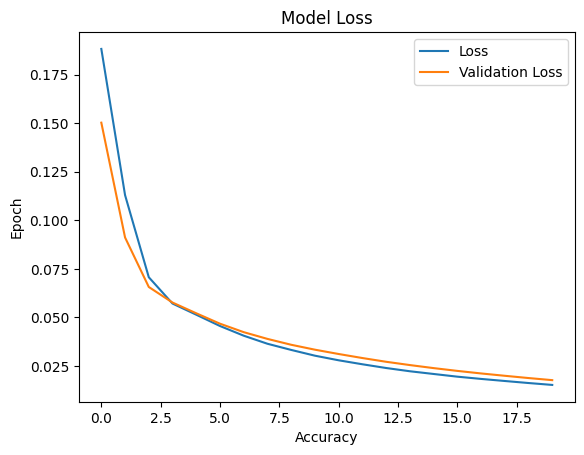

In [72]:
plt.plot(history.history['loss'], label = "Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title("Model Loss")
plt.xlabel("Accuracy")
plt.ylabel("Epoch")

plt.show()

In [73]:
from tensorflow.keras.layers import BatchNormalization

In [74]:
model1 = Sequential()
model1.add(Dense(7, activation='relu', input_dim=7))
model1.add(BatchNormalization())
model1.add(Dense(3, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dense(1, activation='linear'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
model1.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                     │ (None, 7)                   │              56 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 7)                   │              28 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 3)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 3)                   │              12 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 124 (496.00 B)

 Trainable params: 104 (416.00 B)

 Non-trainable params: 20 (80.00 B)

In [76]:
model1.compile(loss='mean_squared_error', optimizer='Adam')

In [77]:
history1 = model1.fit(x_train, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 1.2728 - val_loss: 0.2932
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9089 - val_loss: 0.2835
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7197 - val_loss: 0.2665
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6480 - val_loss: 0.2443
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5642 - val_loss: 0.2207
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5057 - val_loss: 0.1965
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4388 - val_loss: 0.1752
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3916 - val_loss: 0.1578
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3525 - val_loss: 0.1418
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3183 - val_loss: 0.1269
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2877 - val_loss: 0.1122
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2618 - val_l

In [78]:
y_pred1 = model1.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


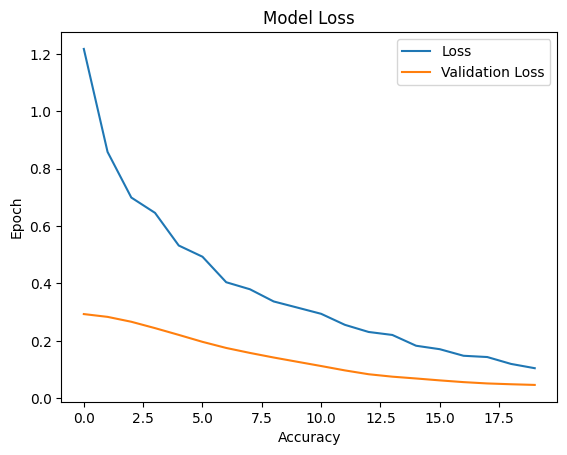

In [97]:
plt.plot(history1.history['loss'], label = "Loss")
plt.plot(history1.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title("Model Loss")
plt.xlabel("Accuracy")
plt.ylabel("Epoch")

plt.show()

In [80]:
df1 = pd.read_csv('/content/Power Plant Data.csv')

In [81]:
df1

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


In [82]:
x = df1.iloc[:, :-1].values
y = df1.iloc[:, -1].values

In [83]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [84]:
scaler = StandardScaler()

In [85]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [86]:
model2 = Sequential()
model2.add(Dense(6, activation='relu', input_dim=4))
model2.add(Dense(6, activation='relu'))
model2.add(Dense(1, activation='linear'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [87]:
model2.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                     │ (None, 6)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 6)                   │              42 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 1)                   │               7 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79 (316.00 B)

 Trainable params: 79 (316.00 B)

 Non-trainable params: 0 (0.00 B)

In [88]:
model2.compile(loss='mean_squared_error', optimizer='Adam')

In [89]:
history2 = model2.fit(x_train, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 205347.2188 - val_loss: 200162.9219
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 196430.2500 - val_loss: 179225.7969
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 170027.7344 - val_loss: 135248.6719
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 120711.7422 - val_loss: 80215.5234
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 68530.7812 - val_loss: 40255.1914
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34848.0508 - val_loss: 22216.0371
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20606.0645 - val_loss: 16043.2217
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15737.6758 - val_loss: 13148.1855
Epoch 9/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12870.2266 - val_loss: 10691.5039
Epoch 10/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10337.6738 - val_loss: 8448.4238
Epoch 11/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 

In [90]:
y_pred2 = model2.predict(x_test)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


Text(0.5, 0, 'Epoch')

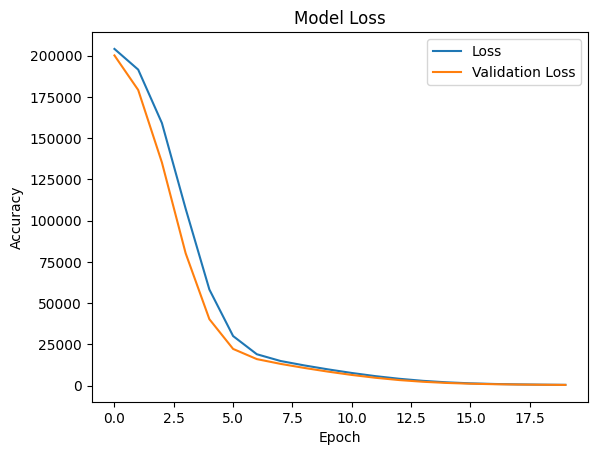

In [98]:
plt.plot(history2.history['loss'], label = "Loss")
plt.plot(history2.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

In [92]:
model3 = Sequential()
model3.add(Dense(6, activation='relu', input_dim=4))
model3.add(BatchNormalization())
model3.add(Dense(6, activation='relu'))
model3.add(BatchNormalization())
model3.add(Dense(1, activation='linear'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [93]:
model3.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                     │ (None, 6)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 6)                   │              24 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 6)                   │              42 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 6)                   │              24 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 1)                   │               7 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 127 (508.00 B)

 Trainable params: 103 (412.00 B)

 Non-trainable params: 24 (96.00 B)

In [94]:
model3.compile(loss='mean_squared_error', optimizer='Adam')

In [95]:
history3 = model3.fit(x_train, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 206688.9844 - val_loss: 204731.9688
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 204802.3594 - val_loss: 203586.1250
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 202432.0312 - val_loss: 200833.1562
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 199295.3438 - val_loss: 196735.0781
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 195291.9688 - val_loss: 192350.4375
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 190635.6406 - val_loss: 186897.8125
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 185635.8594 - val_loss: 180239.2656
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 179298.2812 - val_loss: 173691.2188
Epoch 9/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 172873.3125 - val_loss: 167260.9531
Epoch 10/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 165650.2500 - val_loss: 160036.4219
Epoch 11/20
192/192 ━━━━━━━━━━━━━━━━━━━

In [96]:
y_pred3 = model3.predict(x_test)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


Text(0.5, 0, 'Epoch')

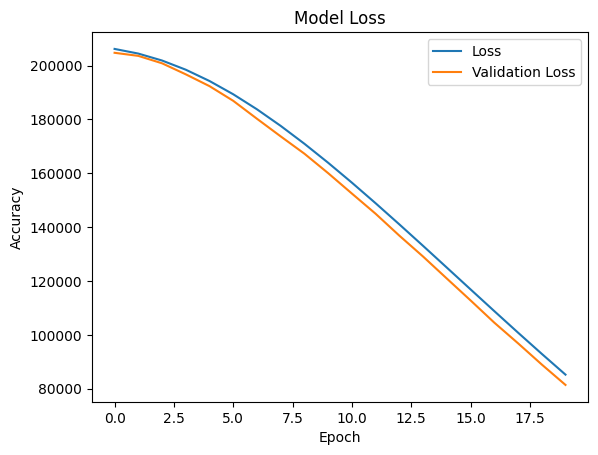

In [99]:
plt.plot(history3.history['loss'], label = "Loss")
plt.plot(history3.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')